In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
print(os.getcwd())

/mnt/cold1/snaketree/prj/scRNA/dataset/Graph_NN/notebook


In [3]:
#Leggo dati
data_path='/mnt/cold1/snaketree/prj/scRNA/dataset/rCASC_Ire_cetuxi/CRC0322_NT_1_3000_dir/annotated_CRC0322_NT_1_3000.tsv'
data=pd.read_csv(data_path,header=0,index_col=0,sep=',').T
data.columns = [col.split(":")[1] if ":" in col else col for col in data.columns]

In [4]:
# salvo il dataframe in un annData e metto nomi di variabilie e obs unici(controllo che non ci siano geni con nomi duplicati)
adata = sc.AnnData(data,dtype='float64')
adata


/usr/local/mamba/envs/scampyno/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 3000 × 19360

In [5]:
adata.var_names_make_unique()
adata.obs_names_make_unique()

In [6]:
adata

AnnData object with n_obs × n_vars = 3000 × 19360

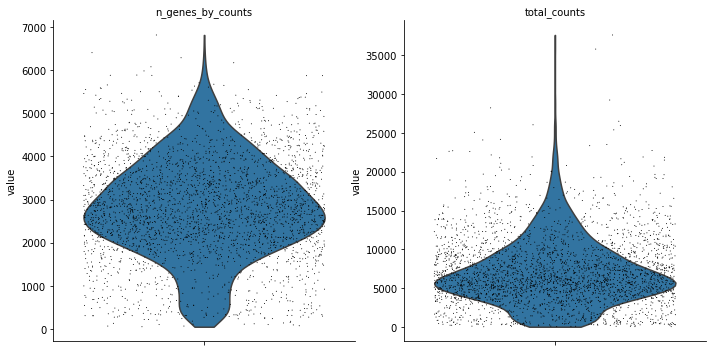

In [7]:
#QC plot

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo"], inplace=True, log1p=True
)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)


In [8]:
adata

AnnData object with n_obs × n_vars = 3000 × 19360
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [9]:
#STEP 2


#Filtro cellule morte e geni espressi in poche cellule
#Di solito noi per le filtrare le cellule facciamo un filtro un pochino piu complesso, quello di scanpy filtra
# le cellule se hanno almeno 100 geni espressi(in scanpy geni espressi == ha almeno un count )
# Noi invece di solito definiamo gene espresso come ha almeno 3 counts 
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [10]:
adata

AnnData object with n_obs × n_vars = 2995 × 13657
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [23]:
adata.layers["counts"] = adata.X.copy()

adata

AnnData object with n_obs × n_vars = 2995 × 13657
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: 'counts'

In [7]:
adata.layers['counts']

array([[1., 0., 2., ..., 0., 0., 0.],
       [1., 0., 2., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [3., 2., 2., ..., 0., 0., 0.]])

In [11]:
#STEP3
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [14]:
print(adata)

AnnData object with n_obs × n_vars = 2995 × 13657
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'


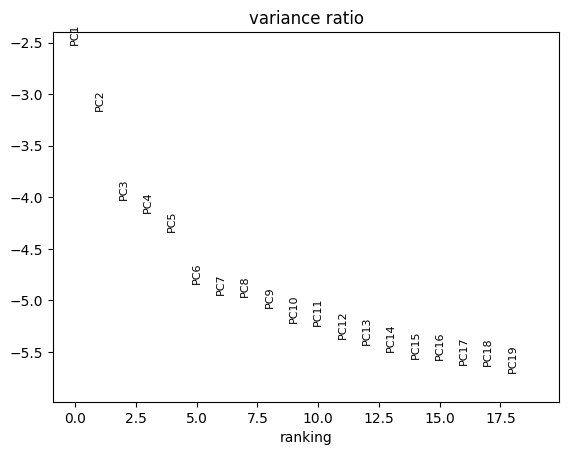

In [13]:
#STEP final 
#input: filtered_normalized bla bla
#output: plot pca, compionenti UMAP (X,Y) in csv, output del clustering come csv in cui c'è una colonna che ha id_cellula,
# e cluster associato 
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata,n_comps=19) #salvare plot 
sc.pl.pca_variance_ratio(adata, n_pcs=19, log=True)

In [15]:
sc.pp.neighbors(adata)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [17]:
adata


AnnData object with n_obs × n_vars = 2995 × 13657
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [ ]:
adata

array([[0.71311309, 0.        , 1.12514588, ..., 0.        , 0.        ,
        0.        ],
       [0.83265193, 0.        , 1.28060519, ..., 0.        , 0.        ,
        0.        ],
       [0.60739896, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.66209227, 0.        , 0.66209227, ..., 0.        , 0.        ,
        0.        ],
       [0.58855506, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [1.28548655, 1.00952047, 1.00952047, ..., 0.        , 0.        ,
        0.        ]])

In [19]:
sc.tl.umap(adata)

In [20]:
adata

AnnData object with n_obs × n_vars = 2995 × 13657
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [25]:
adata.obsm['X_umap']

array([[ 6.3209224 , -0.5438676 ],
       [-3.9672406 ,  3.650129  ],
       [ 1.1086367 , -1.5064578 ],
       ...,
       [-2.6390111 ,  3.7548378 ],
       [ 0.14848557, -0.30770692],
       [-0.09344541,  1.8720658 ]], dtype=float32)

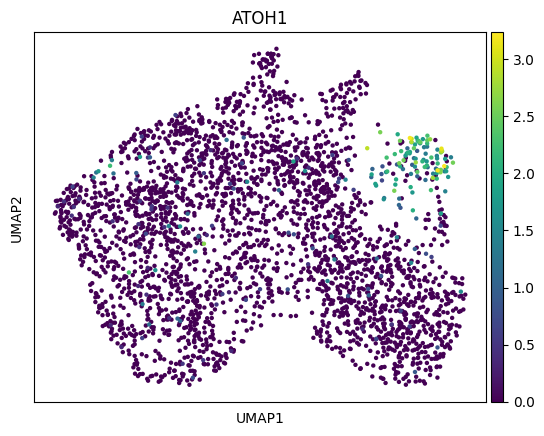

In [27]:
sc.pl.umap(
    adata,
    color="ATOH1"
)

In [28]:
adata

AnnData object with n_obs × n_vars = 2995 × 13657
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [32]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,n_genes
CATGGATGTGTGTGGA.1,2364,7.768533,6124.0,8.720134,30.992815,38.553233,47.942521,63.096016,0.0,0.0,0.0,0.0,0.0,0.0,2364
TAGAGTCAGTACTGTC.1,2294,7.738488,4903.0,8.497806,19.926576,27.942076,38.058332,56.271670,0.0,0.0,0.0,0.0,0.0,0.0,2294
AGGTAGGAGATGCAGC.1,3011,8.010360,7625.0,8.939319,25.442623,32.826230,41.639344,56.340984,0.0,0.0,0.0,0.0,0.0,0.0,3011
CATGCCTAGGTGCCTC.1,4918,8.500861,17013.0,9.741792,21.230823,28.019750,36.219362,50.138130,0.0,0.0,0.0,0.0,0.0,0.0,4918
TGAATGCAGAACCGCA.1,3659,8.205218,9334.0,9.141526,21.877009,28.422970,36.554532,51.146347,0.0,0.0,0.0,0.0,0.0,0.0,3659
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GATTGGTTCAAGGTGG.1,3729,8.224164,10450.0,9.254453,19.100478,25.961722,35.090909,51.349282,0.0,0.0,0.0,0.0,0.0,0.0,3729
GACTCTCTCGCCCAGA.1,2374,7.772753,4430.0,8.396381,19.051919,25.620767,35.056433,51.851016,0.0,0.0,0.0,0.0,0.0,0.0,2374
AGCGTCGCACCCTTGT.1,3124,8.047190,6786.0,8.822764,17.860301,24.300029,32.935455,48.983201,0.0,0.0,0.0,0.0,0.0,0.0,3124
CGAGAAGCAGAGAGGG.1,2980,8.000014,7951.0,8.981179,25.179223,32.536788,41.768331,57.099736,0.0,0.0,0.0,0.0,0.0,0.0,2980


In [30]:
adata.obsm['X_umap']

array([[ 6.3209224 , -0.5438676 ],
       [-3.9672406 ,  3.650129  ],
       [ 1.1086367 , -1.5064578 ],
       ...,
       [-2.6390111 ,  3.7548378 ],
       [ 0.14848557, -0.30770692],
       [-0.09344541,  1.8720658 ]], dtype=float32)

risoluzione:1


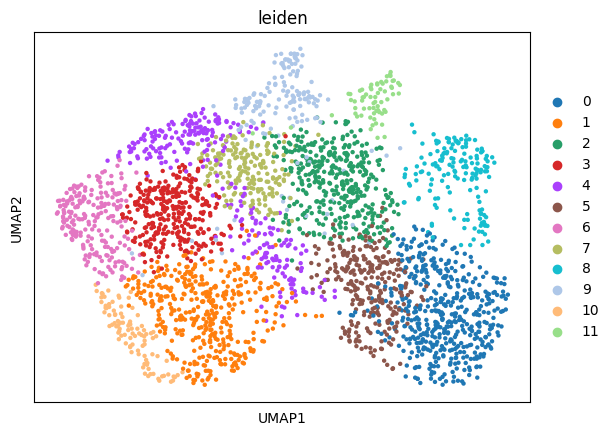

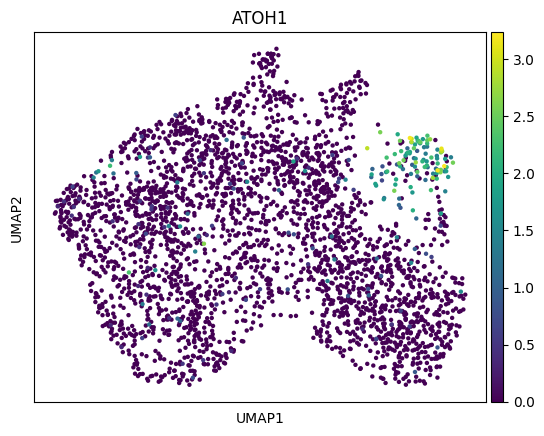

risoluzione:0.7


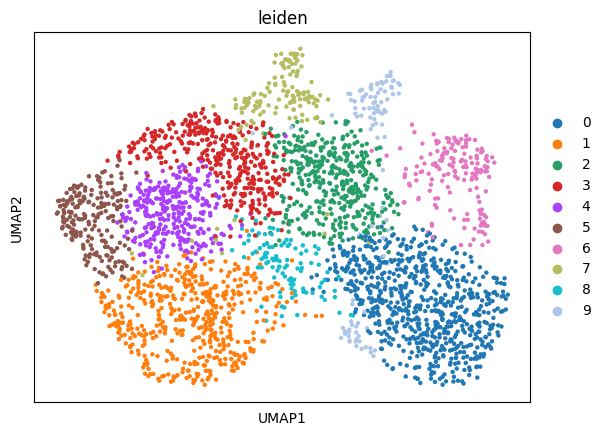

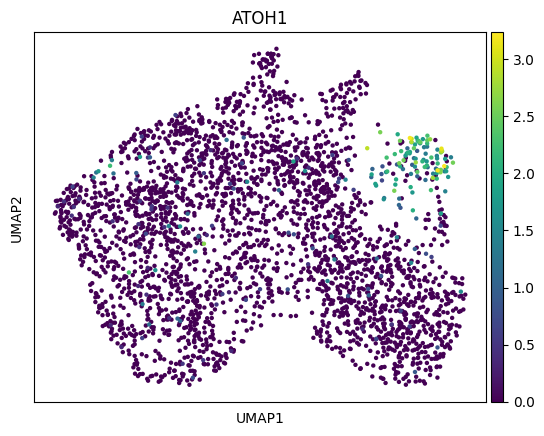

risoluzione:0.3


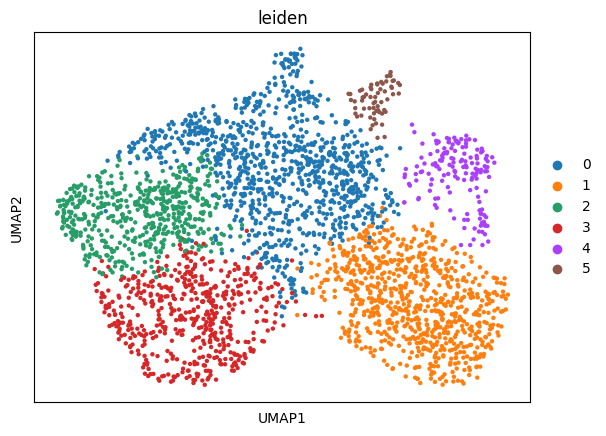

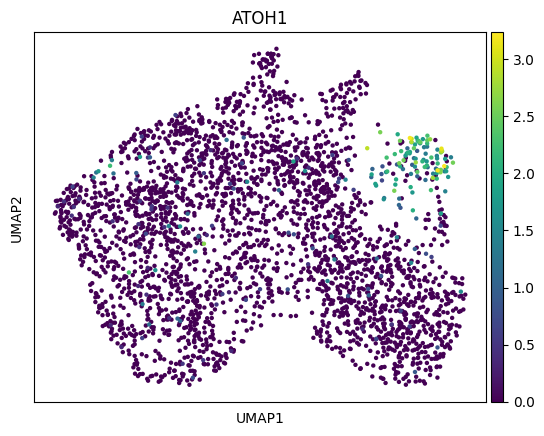

risoluzione:0.15


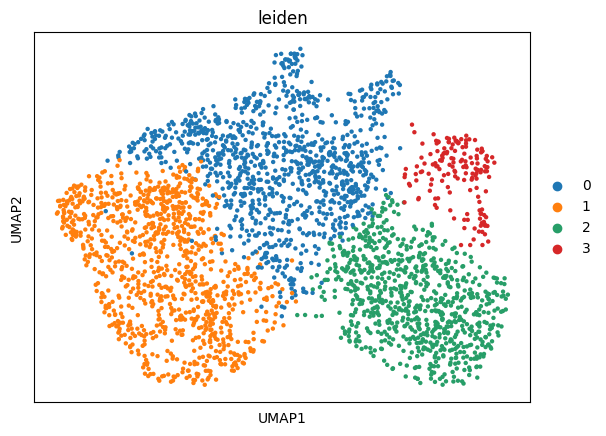

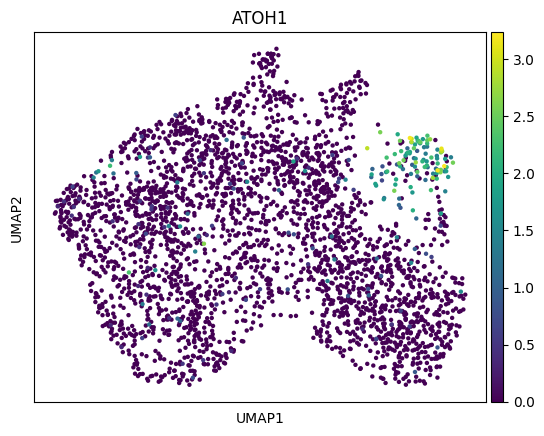

In [33]:
for r in [1,0.7,0.3,0.15]:
    print('risoluzione:'+str(r))
    sc.tl.leiden(adata, resolution=r)
    sc.pl.umap(
    adata,
    color="leiden")
    sc.pl.umap(
    adata,
    color="ATOH1")
    

In [35]:
adata

AnnData object with n_obs × n_vars = 2995 × 13657
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'leiden'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [45]:
adata.obs['leiden'].values

['2', '1', '1', '1', '2', ..., '0', '0', '1', '1', '1']
Length: 2995
Categories (4, object): ['0', '1', '2', '3']

In [95]:
sc.tl.rank_genes_groups(adata,groupby='leiden')

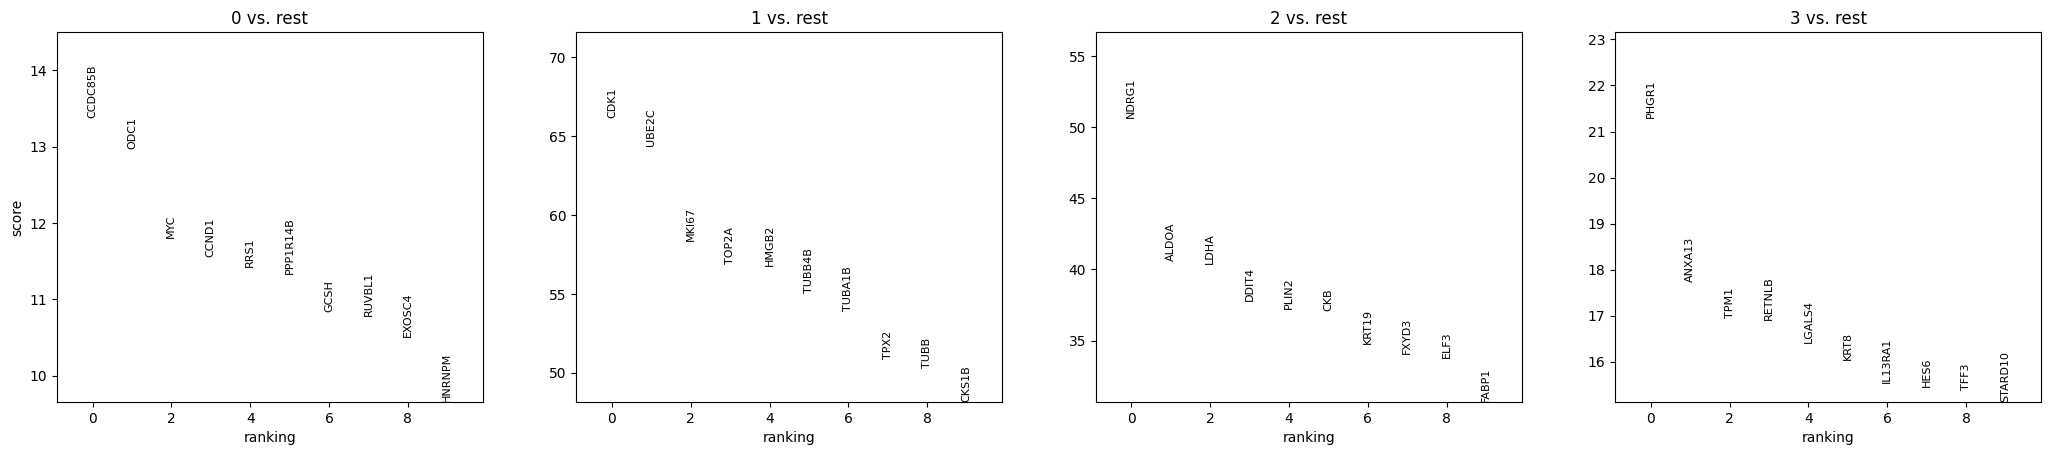

In [97]:
sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)